In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import os
import random

In [2]:
fontsize = 16
fontsize_minor = 12


/tmp/ipykernel_3931938/739917302.py:16: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_3931938/739917302.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_3931938/739917302.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


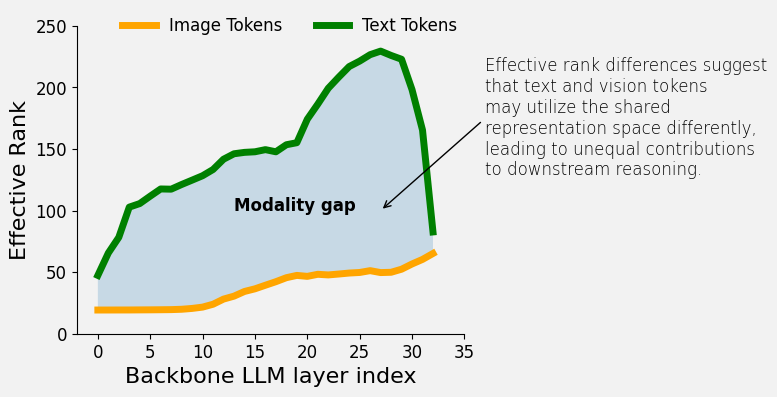

In [35]:
### gap illustartion
fig,ax = plt.subplots(1,1,figsize=(5,4))

model = 'llava-v1.6-mistral-7b',

path = '../../results/llava-v1.6-mistral-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv'

df = pd.read_csv(path, index_col=0).reset_index(names="sample")
df = df[df['sample']==0]
df = df.drop(['sample'],axis=1)

df = df.melt(['Mean over','contains'])
df['layers'] = df['variable'].astype(int)
    
    
b = sns.lineplot(
    data=df[
        (df['Mean over']!='All tokens') 
        & (df['Mean over']!='Image only tokens')
        & (df['Mean over']!='Text only tokens')
    ],
    # data=plot_df,
    x='layers',
    y='value',
    hue='Mean over',
    palette=['orange','green', 'lightgreen', 'red'],
    err_style='bars',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax,
    linewidth=5
)


# --- choose the two curves you want to fill between ---
curve_a = "Img tokens"   # <-- replace with exact label in df['Mean over']
curve_b = "Text tokens"     # <-- replace with exact label in df['Mean over']

sub = df[
    (df['Mean over'] != 'Image only tokens') &
    (df['Mean over'] != 'Text only tokens')
].copy()

# pivot so each curve becomes a column, aligned by layer
wide = (sub[sub["Mean over"].isin([curve_a, curve_b])]
        .pivot_table(index="layers", columns="Mean over", values="value", aggfunc="mean")
        .sort_index())

x = wide.index.to_numpy()
y1 = wide[curve_a].to_numpy()
y2 = wide[curve_b].to_numpy()

# fill between the two curves
ax.fill_between(x, y1, y2, alpha=0.2)

# --- Set other parameters ---

b.set(ylim=(0,250), xlim=(-2,35))
    
b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
b.set_ylabel('Effective Rank', fontsize=fontsize)
b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.legend(
    labels=['Image Tokens', 'Text Tokens'],
    loc=(0.1,0.95),
    ncols=2,
    frameon=False, 
    fontsize=fontsize_minor,
    
)

b.text(
    x=13,
    y=100,
    s="Modality gap",
    fontweight='bold',
    fontsize=fontsize_minor
)



ax.annotate(
        (
        "Effective rank differences suggest\n" 
        "that text and vision tokens\n"
        "may utilize the shared\n"
        "representation space differently,\n"
        "leading to unequal contributions\n"
        "to downstream reasoning."
    ),
    xy=(27, 100),
    xytext=(37,175),
    arrowprops=dict(
        arrowstyle="->", 
        linewidth=1,
        connectionstyle="arc3,rad=0" ,
        relpos=(0, 0.5)
    ),
    fontsize=12,
    fontweight=299,
    ha="left",
    va="center",
)

sns.despine(top=True, right=True)

ax.set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure

fig.savefig(
    "./../Figures/gap_illustration.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)




/tmp/ipykernel_4141055/47673888.py:36: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_4141055/47673888.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_4141055/47673888.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_4141055/47673888.py:36: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_4141055/47673888.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_4141055/47673888.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

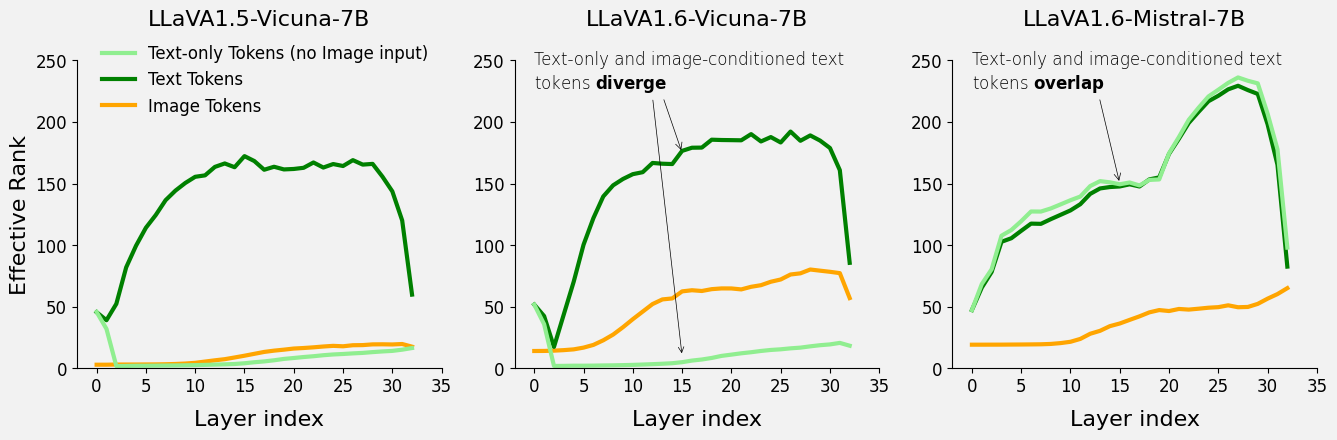

In [3]:
### gap illustartion
fig, ax = plt.subplots(1,3,figsize=(16,4))

model_ls = [
    'LLaVA1.5-Vicuna-7B',
    'LLaVA1.6-Vicuna-7B',
    'LLaVA1.6-Mistral-7B',
]


paths = [
    '../../results/llava-1.5-7b/svd/token/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
    '../../results/llava-v1.6-vicuna-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
    '../../results/llava-v1.6-mistral-7b/svd/svd_effective_rank_image_and_text_gray_cylinder_7.csv',
]

backbone_ls = [
    'LLaVA1.5-Vicuna-7B',
    'LLaVA1.6-Vicuna-7B',
    'LLaVA1.6-Mistral-7B',
]


for idx, path in enumerate(paths):
    df = pd.read_csv(path, index_col=0)
    if 'sample' not in df.columns:
        df = df.reset_index(names="sample" if 'sample' not in df.columns else 'Unnamed')
    df = df[df['sample']==0]
    
    df = df.drop(['sample'],axis=1) if 'label' not in df.columns else df.drop(['sample','label'],axis=1)
    
    df = df.melt(['Mean over','contains'])
    df['layers'] = df['variable'].astype(int)
        
        
    b = sns.lineplot(
        data=df[
            (df['Mean over']!='All tokens') 
            & (df['Mean over']!='Image only tokens')
            # & (df['Mean over']!='Text only tokens')
        ],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        err_style='bars',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[idx],
        linewidth=3
    )
    
    
    b.set(ylim=(0,250), xlim=(-2,35))
    b.set_title(
        model_ls[idx],
        pad=25,
        fontsize=fontsize,
    )
    
    b.set_xlabel(f'Layer index', labelpad=10, fontsize=fontsize)
    if idx==0:
        b.set_ylabel('Effective Rank', fontsize=fontsize)
    else:
        b.set_ylabel('', fontsize=fontsize)
        
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    handles, labels = b.get_legend_handles_labels()
    
    order = [
        'Text only tokens',
        'Text tokens',
        'Img tokens',
    ]
    
    label_map = {
        'Text only tokens': 'Text-only Tokens (no Image input)',
        'Text tokens': 'Text Tokens',
        'Img tokens': 'Image Tokens',
    }
    
    # reorder handles and relabel
    handles = [handles[labels.index(o)] for o in order]
    labels  = [label_map[o] for o in order]

    if idx==0:
        b.legend(
            handles,
            labels,
            loc=(0.05,0.8),
            ncols=1,
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()

    if idx==1:
        ax[idx].annotate(
            text=(
                "Text-only and image-conditioned text\n"
                r"tokens $\bf{diverge}$"
            ),
            xy=(15, 175),          # between the two curves
            xytext=(0, 240),
            arrowprops=dict(
                arrowstyle="->", 
                lw=0.5,
                relpos=(0.4, 0.25), 
            ),
            ha="left",
            va="center",
            fontsize=12,
            fontweight=299,
        )

        ax[idx].annotate(
            "",
            xy=(15, 10),
            xytext=(12, 220),
            arrowprops=dict(
                arrowstyle="->",
                lw=0.5,
                connectionstyle="arc3,rad=0",
                relpos=(0.4, 0.25), 
            ),
        )

    if idx==2:
        ax[idx].annotate(
            text=(
                "Text-only and image-conditioned text\n"
                r"tokens $\bf{overlap}$"
            ),
            xy=(15, 150),          # overlapping region
            xytext=(0, 240),
            arrowprops=dict(
                arrowstyle="->", 
                lw=0.5,
                relpos=(0.4, 0.25), 
            ),
            fontsize=12,
            fontweight=299,
            ha="left",
            va="center",
        )

    ax[idx].set_facecolor((0.95, 0.95, 0.95))
fig.patch.set_facecolor((0.95, 0.95, 0.95))  # whole figure


sns.despine(top=True, right=True)



fig.savefig(
    "./../Figures/vicuna_vs_mistral.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)




In [6]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

In [115]:
# df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
embedding_cols = [c for c in df.columns if c.isdigit()]

total_df_

,Prediction,eRank_diff,model,ds,gap_z,pred_c,gap_bin
0,1,311.532843,llava-v1.6-vicuna-7b,MATE,-0.537257,0.84,3
1,1,406.732735,llava-v1.6-vicuna-7b,MATE,-0.170881,0.84,5
2,0,665.955726,llava-v1.6-vicuna-7b,MATE,0.826736,-0.16,8
3,0,438.562338,llava-v1.6-vicuna-7b,MATE,-0.048385,-0.16,5
4,1,360.439110,llava-v1.6-vicuna-7b,MATE,-0.349042,0.84,4
...,...,...,...,...,...,...,...
45,1,5252.794928,Qwen3-VL-8B-Instruct,BLINK,-0.227459,0.50,5
46,0,47067.157144,Qwen3-VL-8B-Instruct,BLINK,3.619221,-0.50,9
47,1,203.460070,Qwen3-VL-8B-Instruct,BLINK,-0.691968,0.50,2
48,0,9240.325150,Qwen3-VL-8B-Instruct,BLINK,0.139371,-0.50,6


/tmp/ipykernel_284774/312409701.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284774/312409701.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284774/312409701.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284774/312409701.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284774/312409701.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284774/312409701.py:150: UserWarning: se

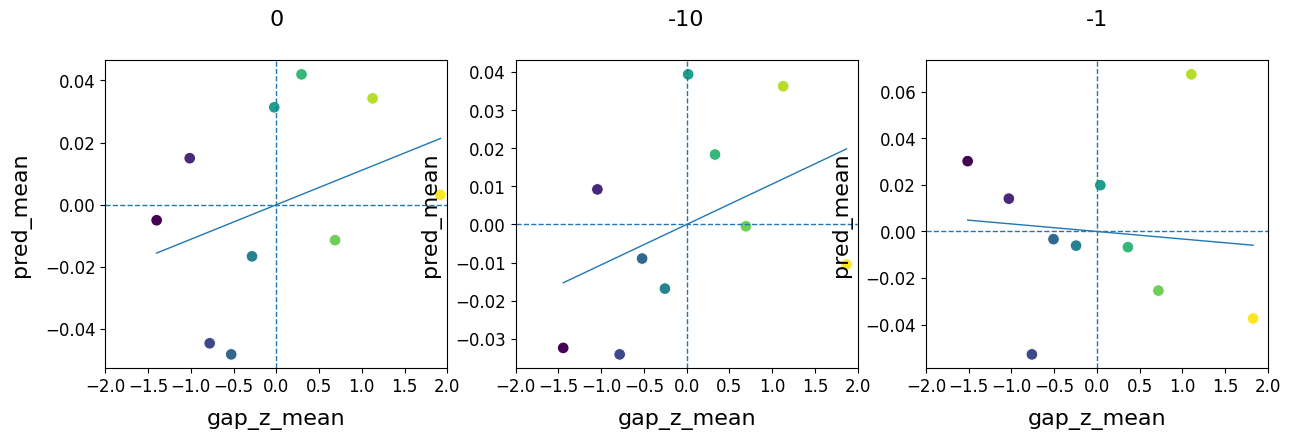

In [5]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

# fig, axes = plt.subplots(nrows=len(model_ls), ncols=1, figsize=(7.5, 20))
# axes = axes.flatten()
lastn=-1
# lastn = int(3*len(embedding_cols)/4)
lastn = 0
lastns = [0, -10, -1]


fig,ax = plt.subplots(1,3,figsize=(15,4))
ax = ax.flatten()

for i, lastn in enumerate(lastns):
    total_df = []
    for idx, model_name in enumerate(model_ls):
        plot_df = []
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
                pass
            elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
                pass
            elif ds_name=='VstarBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
    
                if ds_name=='MATE':
                    df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]
    
                # create prediction correct or not column
                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                
                embedding_cols = [c for c in df.columns if c.isdigit()]
                
                embedding_cols = embedding_cols[lastn:]
                
                # plot x and y
                # print(embedding_cols, len(embedding_cols))
                
                y = np.sqrt(np.sum(
                            (df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                            df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2, 
                            axis=1
                    )/len(embedding_cols)
                )
                
                # plot x and y
                x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
                
                plot_df_ds = pd.DataFrame({
                    'Prediction':x,
                    'eRank_diff':y,
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
                total_df = total_df + [plot_df_ds]
        plot_df = pd.concat(plot_df)
    
    total_df = pd.concat(total_df)
    
    total_df_ = total_df.copy()
    
    # z-score eRank_diff within each (dataset, model)
    total_df_["gap_z"] = (
        total_df_.groupby(["ds", "model"])["eRank_diff"]
          .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )
    
    # center correctness (Prediction) within each (dataset, model)
    total_df_["pred_c"] = (
        total_df_.groupby(["ds", "model"])["Prediction"]
          .transform(lambda x: x - x.mean())
    )
    
    
    # bin gap_z into quantiles (globally is fine after normalization)
    total_df_["gap_bin"] = pd.qcut(total_df_["gap_z"], q=10, labels=False, duplicates="drop")
    
    plot_df_ = (
        total_df_.groupby("gap_bin")
          .agg(
              gap_z_mean=("gap_z", "mean"),
              pred_mean=("pred_c", "mean"),
              n=("pred_c", "size"),
          )
          .reset_index()
    )


    ########### PLOT
    b = sns.scatterplot(
        data=plot_df_,
        x="gap_z_mean",
        y="pred_mean",
        hue="gap_bin",
        palette="viridis",
        s=70,
        ax=ax[i],
        legend="brief"
    )
    
    b.axhline(0, linestyle="--", linewidth=1)
    b.axvline(0, linestyle="--", linewidth=1)
    
    b.set_xlabel("Normalized eRank gap (z-score)", labelpad=10, fontsize=fontsize)
    b.set_ylabel("Centered correctness", labelpad=10, fontsize=fontsize)
    
    b.set(xlim=(-2,2))
    b.set_title(
       # "Within-dataset normalized gap vs outcome",
        f"{lastn}",
        pad=25,
        fontsize=fontsize,
    )
    
        
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )
    
    
    # q1 = plot_df_["pred_mean"].quantile(0.25)
    # q3 = plot_df_["pred_mean"].quantile(0.75)
    # iqr = q3 - q1
    
    
    # mask = (plot_df_["pred_mean"] >= q1 - 1.5 * iqr) & \
    #        (plot_df_["pred_mean"] <= q3 + 1.5 * iqr)
    
    # filtered = plot_df_[mask]
    
    # sns.regplot(
    #     data=filtered,
    #     y="pred_mean",
    #     x="gap_z_mean",
    #     ci=None,
    #     scatter=False,
    #     ax=b,
    #     line_kws={"lw": 1}
    # )
    sns.regplot(data=plot_df_, y="pred_mean", x="gap_z_mean", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})
                
    # b.legend(
    #     loc=(0.05,0.8),
    #     ncols=1,
    #     frameon=False, 
    #     fontsize=fontsize_minor,
    # )
    
    b.legend_.remove()
# sns.despine(top=True, right=True)

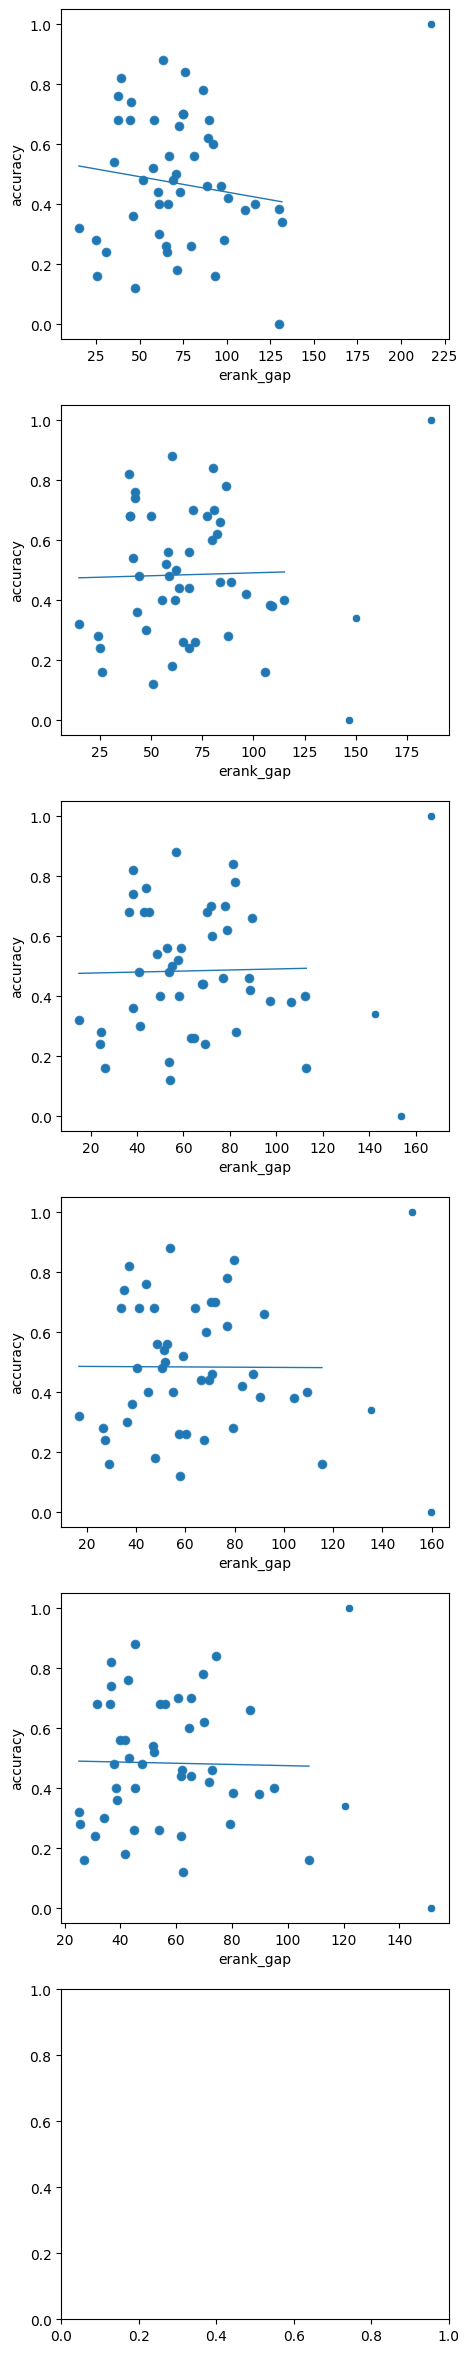

In [8]:

model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(5, 30))
axes = axes.flatten()

for idx, lastn in enumerate([-5, -10, -15, -20, 0]):
    plot_df = []
    for model_name in model_ls:
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-3B']:
                pass
            elif ds_name=='MicroVQA' and model_name in ['llava-1.5-7b','Qwen3-VL-8B-Instruct']:
                pass
            elif ds_name=='VstarBench' and model_name in ['llava-1.5-7b','Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
                
                # create prediction correct or not column
                if ds_name=='MATE':
                    df['gold_referencewImg'] = [i[1].split("}")[0].lstrip('"').rstrip('"') for i in df['gold_referencewImg'].str.split(": ")]

                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                embedding_cols = [c for c in df.columns if c.isdigit()]
                embedding_cols = embedding_cols[lastn:]
                
                # plot x and y
                x = [df[df['Mean over']=='Text tokens']['verdict'].to_numpy().sum()/len(df[df['Mean over']=='Text tokens'])]
                if x[0]!=2.0:
                    # y = [np.linalg.norm(df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())]
                    y = np.sum((
                            df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                            df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2
                        )/len(embedding_cols*len(df[df['Mean over']=='Text tokens']))
                    y = [np.sqrt(y)]
        
                    plot_df_ds = pd.DataFrame({
                        'accuracy':x,
                        'erank_gap':y,
                        # 'hue': hue,
                        'model': [model_name]*len(x),
                        'ds': [ds_name]*len(x)
                    })
                    plot_df = plot_df + [plot_df_ds]
            
    plot_df = pd.concat(plot_df)
        
    b = sns.scatterplot(
        data=plot_df,
        y='accuracy',
        x='erank_gap',
        # hue='Prediction',
        ax=axes[idx],
    )

    q1 = plot_df["erank_gap"].quantile(0.25)
    q3 = plot_df["erank_gap"].quantile(0.75)
    iqr = q3 - q1
    
    mask = (plot_df["erank_gap"] >= q1 - 1.5 * iqr) & \
           (plot_df["erank_gap"] <= q3 + 1.5 * iqr)
    
    filtered = plot_df[mask]
    
    sns.regplot(
        data=filtered,
        y="accuracy",
        x="erank_gap",
        ci=None,
        scatter=True,
        ax=b,
        line_kws={"lw": 1}
    )

    # sns.regplot(data=plot_df, y="accuracy", x="erank_gap", ci=None,
    #     scatter=True, ax=b, line_kws={"lw":1})
# b.set_title(model_name)

<Axes: xlabel='erank_gap', ylabel='accuracy'>

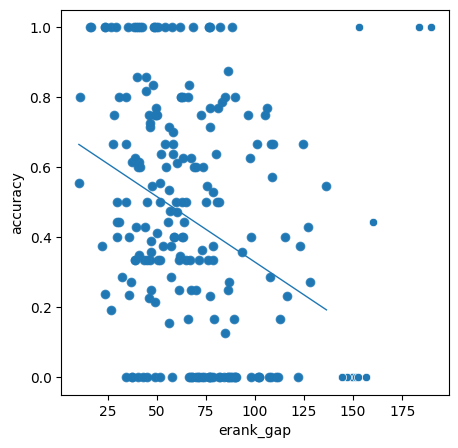

In [10]:

model_ls = [
    # 'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
# axes = axes.flatten()

plot_df = []
for idx, model_name in enumerate(model_ls):
    for ds_name in ds_names:
        if ds_name=='HallusionBench' and model_name=='Qwen2.5-VL-3B':
            pass
        elif ds_name=='MicroVQA' and model_name=='Qwen3-VL-8B-Instruct':
            pass
        elif ds_name=='MathVision' and 'Qwen' not in model_name: #in ['molmoD-7B', 'llava-v1.6-mistral-7b']:
            pass
        elif ds_name=='VstarBench' and model_name in ['Qwen2.5-VL-7B','Qwen3-VL-4B-Instruct','Qwen3-VL-8B-Instruct']:
            pass
        else:
            current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
            
            # read dataset
            df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
            
            # create prediction correct or not column
            df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
            embedding_cols = [c for c in df.columns if c.isdigit()][-10:]

            for tg in df['tagwImg'].unique():
                df_ = df[df['tagwImg']==tg]
                # plot x and y
                x = [df_[df_['Mean over']=='Text tokens']['verdict'].to_numpy().sum()/len(df_[df_['Mean over']=='Text tokens'])]
                y = np.sum((
                        df_[df_['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                        df_[df_['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2
                    )/len(embedding_cols*len(df_[df_['Mean over']=='Text tokens']))
                y = [np.sqrt(y)]
                # hue = df[df['Mean over']=='Text tokens']['tagwImg'].to_list()
                plot_df_ds = pd.DataFrame({
                    'accuracy':x,
                    'erank_gap':y,
                    'erank_gap_log': np.log(y),
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
            
plot_df = pd.concat(plot_df)
b = sns.scatterplot(
    data=plot_df,
    y='accuracy',
    x='erank_gap',
    # hue='Prediction',
    ax=axes,
)

q1 = plot_df["erank_gap"].quantile(0.25)
q3 = plot_df["erank_gap"].quantile(0.75)
iqr = q3 - q1

mask = (plot_df["erank_gap"] >= q1 - 1.5 * iqr) & \
       (plot_df["erank_gap"] <= q3 + 1.5 * iqr)

filtered = plot_df[mask]

sns.regplot(
    data=filtered,
    y="accuracy",
    x="erank_gap",
    ci=None,
    scatter=True,
    ax=b,
    line_kws={"lw": 1}
)

# b.set_title(model_name)

<Axes: xlabel='variable', ylabel='value'>

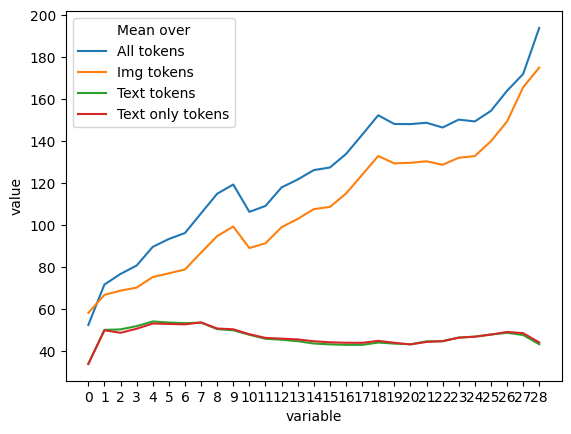

In [38]:

df_ = df[df['idx_corrected']==327]
df_ = df_[embedding_cols+['Mean over']].melt(['Mean over'])

sns.lineplot(
    data=df_,
    x='variable',
    y='value',
    hue='Mean over'
)


In [12]:
model_name = 'Qwen2.5-VL-3B'
ds_name = 'ScienceQA'
pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,idx_corrected,idx_main,outputwImg,predictionwImg,gold_referencewImg,tagwImg,outputwoImg,predictionwoImg,gold_referencewoImg,tagwoImg
0,0,2.989293,21.606410,22.432560,15.507114,17.613504,22.453465,27.432238,33.781723,38.459610,...,114,416,system\nYou are a helpful assistant.\nuser\n Q...,0,0,grade3,system\nYou are a helpful assistant.\nuser\n Q...,1,0,grade3
1,1,3.299399,30.309513,31.727879,27.374235,33.674580,43.394672,51.359710,62.243576,70.569370,...,25,124,system\nYou are a helpful assistant.\nuser\n Q...,0,0,grade6,system\nYou are a helpful assistant.\nuser\n Q...,1,0,grade6
2,2,2.304045,16.367659,17.886076,11.772790,13.524402,17.561180,21.620785,26.797432,30.571852,...,281,983,system\nYou are a helpful assistant.\nuser\n Q...,2,2,grade8,system\nYou are a helpful assistant.\nuser\n Q...,1,2,grade8
3,3,51.529682,70.080215,69.925290,69.387150,71.387695,74.908760,77.442890,83.347885,85.167030,...,250,897,system\nYou are a helpful assistant.\nuser\n Q...,3,3,grade6,system\nYou are a helpful assistant.\nuser\n Q...,2,3,grade6
4,4,53.146275,71.394230,70.745130,70.007670,72.127210,75.691180,78.920170,85.262600,87.795890,...,228,817,system\nYou are a helpful assistant.\nuser\n Q...,3,2,grade6,system\nYou are a helpful assistant.\nuser\n Q...,2,2,grade6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,45,42.071404,69.650826,74.315010,77.365230,80.635910,83.075370,83.949050,85.631380,85.202700,...,71,292,system\nYou are a helpful assistant.\nuser\n Q...,2,0,grade6,system\nYou are a helpful assistant.\nuser\n Q...,1,0,grade6
196,46,35.691210,54.026047,57.378887,60.122150,63.502495,66.686100,66.903920,69.393936,69.526825,...,46,201,system\nYou are a helpful assistant.\nuser\n Q...,2,2,grade4,system\nYou are a helpful assistant.\nuser\n Q...,1,2,grade4
197,47,25.735065,41.553646,43.680810,45.140150,47.024742,47.814827,48.052467,48.526295,47.760320,...,233,833,system\nYou are a helpful assistant.\nuser\n Q...,3,3,grade4,system\nYou are a helpful assistant.\nuser\n Q...,0,3,grade4
198,48,55.358130,71.821770,75.663315,78.624970,80.454475,84.159390,84.495590,86.825676,87.329760,...,296,1018,system\nYou are a helpful assistant.\nuser\n Q...,3,3,grade8,system\nYou are a helpful assistant.\nuser\n Q...,0,3,grade8
